In [1]:
import sys, torch
print("python:", sys.executable)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)
import subprocess
print(subprocess.check_output("nvidia-smi", shell=True).decode())

python: /home/michaellee/miniconda3/envs/mm/bin/python
torch: 2.12.0+cu130
cuda available: False
cuda version: 13.0


/home/michaellee/miniconda3/envs/mm/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Sat May 23 10:14:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.144                Driver Version: 570.144        CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:1D:00.0 Off |                  Off |
| 45%   71C    P1            166W /  300W |   84355MiB /  97887MiB |     25%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### Step 1: 載入必要的函式庫

In [1]:
import os, cv2, json, tqdm, torch, gc, re, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
from matplotlib.lines import Line2D
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import plotly.graph_objects as go
import open3d as o3d

I0000 00:00:1779239172.262957 1269106 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779239172.543600 1269106 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# 啟用 OpenEXR 支援
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

# 選擇 GPU (0: RTX 6000 Ada, 1/2: RTX PRO 6000 Blackwell, 3: RTX 3090)
GPU_INDEX = 2

if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    # print(f"\n=== Available GPUs ({n_gpus}) ===")
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        mem_gb = props.total_memory / 1024**3
        marker = " <-- selected" if i == GPU_INDEX else ""
        # print(f"  cuda:{i}  {props.name}  ({mem_gb:.1f} GB){marker}")

    assert GPU_INDEX < n_gpus, f"GPU_INDEX={GPU_INDEX} 超出範圍 (只有 {n_gpus} 張)"
    torch.cuda.set_device(GPU_INDEX)
    device = torch.device(f"cuda:{GPU_INDEX}")
    # print(f"\nUsing device: {device} ({torch.cuda.get_device_name(GPU_INDEX)})")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

#### Step 2: 定義核心函數

In [3]:
def get_intrinsic_matrix(height, width):
    """
    獲取相機內參矩陣 K
    
    G-Objaverse 使用固定焦距 fx=fy=1422.222 (基於 1024x1024 解析度)
    主點位於影像中心
    
    K = | fx  0  cx |
        | 0  fy  cy |
        | 0   0   1 |
    """
    fx = fy = 1422.222
    res_raw = 1024
    
    # 根據實際解析度縮放焦距
    f_x = f_y = fx * height / res_raw
    cx = width / 2
    cy = height / 2
    
    K = np.array([
        [f_x, 0, cx],
        [0, f_y, cy],
        [0, 0, 1]
    ], dtype=np.float32)
    
    return K

def read_camera_matrix(json_file):
    """
    讀取相機外參矩陣 (camera-to-world, c2w)
    
    JSON 檔案包含:
    - x: 相機 X 軸方向 (right)
    - y: 相機 Y 軸方向 (up)
    - z: 相機 Z 軸方向 (forward/backward)
    - origin: 相機位置
    
    注意: 需要 flip Y 和 Z 軸來轉換座標系統
    """
    with open(json_file, 'r', encoding='utf8') as f:
        data = json.load(f)
    
    c2w = np.eye(4, dtype=np.float32)
    c2w[:3, 0] = np.array(data['x'])       # X 軸
    c2w[:3, 1] = -np.array(data['y'])      # Y 軸 (flipped)
    c2w[:3, 2] = -np.array(data['z'])      # Z 軸 (flipped)
    c2w[:3, 3] = np.array(data['origin'])  # 相機位置
    
    return c2w

def read_depth_from_exr(exr_path, camera_position):
    """
    從 EXR 檔案讀取深度圖
    
    *_nd.exr 檔案格式:
    - Channel 0-2: Normal (世界座標系)
    - Channel 3: Depth
    
    深度值需要過濾掉 near plane 之前的無效值
    """
    # 計算相機距離原點的距離
    cam_distance = np.linalg.norm(camera_position)
    
    # near plane 設定 (物體被normalize到單位球內)
    near = 0.867  # sqrt(3) * 0.5
    near_distance = cam_distance - near
    
    # 讀取 EXR 檔案
    normald = cv2.imread(exr_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth = normald[..., 3]  # 第4個通道是深度
    
    # 過濾無效深度值
    depth[depth < near_distance] = 0
    
    return depth, normald[..., :3]  # 回傳深度和法向量

def read_rgb_image(img_path):
    """讀取 RGB 影像並轉換到 [0, 1] 範圍"""
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")
    
    # BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 處理 RGBA
    if img.shape[-1] == 4:
        img = img[..., :3]
    
    return img.astype(np.float32) / 255.0

# print("Core functions defined!")

#### Step 3: 2D → 3D 反投影函數 (核心！)

In [4]:
def unproject_depth_to_pointcloud(depth, K, c2w, rgb=None):
    """
    將深度圖反投影到 3D 世界座標點雲
    
    數學公式:
    1. 像素座標 (u, v) + depth → 相機座標 P_cam
       P_cam = K^(-1) @ [u, v, 1]^T * depth
    
    2. 相機座標 → 世界座標
       P_world = c2w @ [P_cam, 1]^T
    
    Args:
        depth: [H, W] 深度圖
        K: [3, 3] 內參矩陣
        c2w: [4, 4] camera-to-world 矩陣
        rgb: [H, W, 3] 可選的顏色圖
    
    Returns:
        points: [N, 3] 世界座標點雲
        colors: [N, 3] 對應的顏色 (如果有提供 rgb)
    """
    H, W = depth.shape
    
    # Step 1: 建立像素座標網格
    u = np.arange(W)
    v = np.arange(H)
    u, v = np.meshgrid(u, v)  # [H, W]
    
    # Step 2: 只取有效深度的點
    valid_mask = depth > 0
    u_valid = u[valid_mask]
    v_valid = v[valid_mask]
    depth_valid = depth[valid_mask]
    
    # Step 3: 像素座標 → 齊次座標
    # [u, v, 1]^T
    ones = np.ones_like(u_valid)
    pixel_coords = np.stack([u_valid, v_valid, ones], axis=0)  # [3, N]
    
    # Step 4: 反投影到相機座標系
    # P_cam = K^(-1) @ [u, v, 1]^T * depth
    K_inv = np.linalg.inv(K)
    cam_coords = K_inv @ pixel_coords  # [3, N]
    cam_coords = cam_coords * depth_valid[np.newaxis, :]  # 乘以深度
    
    # Step 5: 相機座標 → 世界座標
    # P_world = c2w @ [P_cam, 1]^T
    ones_row = np.ones((1, cam_coords.shape[1]))
    cam_coords_homo = np.vstack([cam_coords, ones_row])  # [4, N]
    world_coords = c2w @ cam_coords_homo  # [4, N]
    points = world_coords[:3, :].T  # [N, 3]
    
    # Step 6: 獲取顏色
    colors = None
    if rgb is not None:
        colors = rgb[valid_mask]  # [N, 3]
    
    return points, colors, valid_mask


def convert_pose_flip_yz(c2w):
    """
    Flip Y 和 Z 軸 (用於座標系統轉換)
    這是因為不同軟體使用不同的座標系統慣例
    """
    flip_yz = np.eye(4)
    flip_yz[1, 1] = -1
    flip_yz[2, 2] = -1
    return c2w @ flip_yz

# print("Unprojection functions defined!")

#### Step 4: 設定資料路徑

In [837]:
# 選擇 output_components.json 中第幾筆資料
DATA_INDEX = 49

# 讀進 object_id, question, answer
with open("output_components.json", "r") as f:
    output_components = json.load(f)

object_oc = output_components[DATA_INDEX]
id, name, question, answer = (
    object_oc[k] for k in ["object_id", "object_name", "question", "answer"]
)

# 讀進 point_cloud, multi-view images
with open("./dataset/gobjaverse_to_affogato_nj.json", "r") as f:
    gobjaverse_to_affogato = json.load(f)

object_gta = gobjaverse_to_affogato[DATA_INDEX]
pc_path = f'{object_gta["dst"]}/xyzc.npy'
img_folder_path = object_gta["src"]

# print(f"name: {name}\nid: {id}\nquestion: {question}\nanswer: {answer}")
# print(f"pc_path: {pc_path}\nimg_folder_path: {img_folder_path}")

#### Step 5: 讀取單一視角的資料並視覺化

In [838]:
# 選擇要讀取的視角
VIEW_IDX = 0

# 建立檔案路徑
img_path = f'{img_folder_path}/{VIEW_IDX:05d}/{VIEW_IDX:05d}.png'
depth_path = f'{img_folder_path}/{VIEW_IDX:05d}/{VIEW_IDX:05d}_nd.exr'
json_path = f'{img_folder_path}/{VIEW_IDX:05d}/{VIEW_IDX:05d}.json'

# print(f"Loading view {VIEW_IDX}...")
# print(f"  RGB: {img_path}")
# print(f"  Depth: {depth_path}")
# print(f"  Camera: {json_path}")

# 讀取相機參數
c2w = read_camera_matrix(json_path)
camera_position = c2w[:3, 3]

# print(f"\nCamera position: {camera_position}")
# print(f"Camera distance from origin: {np.linalg.norm(camera_position):.3f}")

# 讀取 RGB 和深度
rgb = read_rgb_image(img_path)
depth, normal = read_depth_from_exr(depth_path, camera_position)

# print(f"\nImage shape: {rgb.shape}")
# print(f"Depth shape: {depth.shape}")
# print(f"Depth range: [{depth[depth>0].min():.3f}, {depth[depth>0].max():.3f}]")

# 視覺化
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# axes[0].imshow(rgb)
# axes[0].set_title('RGB Image')
# axes[0].axis('off')

# im = axes[1].imshow(depth, cmap='viridis')
# axes[1].set_title('Depth Map')
# axes[1].axis('off')
# plt.colorbar(im, ax=axes[1], fraction=0.046)

# # 法向量視覺化 (轉換到 [0, 1] 範圍)
# normal_vis = (normal + 1) / 2
# normal_vis = np.clip(normal_vis, 0, 1)
# axes[2].imshow(normal_vis)
# axes[2].set_title('World Normal')
# axes[2].axis('off')

# plt.tight_layout()
# # plt.show()

#### Step 6: 將單一視角反投影到 3D 點雲

In [839]:
# 獲取內參矩陣
H, W = depth.shape
K = get_intrinsic_matrix(H, W)

# print("Intrinsic Matrix K:")
# print(K)
# print(f"\nFocal length: fx={K[0,0]:.2f}, fy={K[1,1]:.2f}")
# print(f"Principal point: cx={K[0,2]:.2f}, cy={K[1,2]:.2f}")

# 執行反投影
c2w_converted = convert_pose_flip_yz(c2w)
points, colors, valid_mask = unproject_depth_to_pointcloud(depth, K, c2w_converted, rgb)

# print(f"\nGenerated {len(points)} 3D points")
# print(f"Point cloud bounds:")
# print(f"  X: [{points[:, 0].min():.3f}, {points[:, 0].max():.3f}]")
# print(f"  Y: [{points[:, 1].min():.3f}, {points[:, 1].max():.3f}]")
# print(f"  Z: [{points[:, 2].min():.3f}, {points[:, 2].max():.3f}]")

#### Step 7: 視覺化單視角 3D 點雲

In [840]:
def visualize_point_cloud_3d(points, colors=None, title="Point Cloud", 
                              camera_positions=None, subsample=5):
    """
    使用 matplotlib 視覺化 3D 點雲
    
    Args:
        points: [N, 3] 點雲座標
        colors: [N, 3] 點的顏色
        camera_positions: list of [3,] 相機位置 (可選)
        subsample: 降採樣倍率 (加速視覺化)
    """
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Downsampling 以加速視覺化
    idx = np.arange(0, len(points), subsample)
    pts = points[idx]
    
    if colors is not None:
        cols = colors[idx]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], 
                   c=cols, s=1, alpha=0.6)
    else:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], 
                   s=1, alpha=0.6)
    
    # 繪製相機位置
    if camera_positions is not None:
        cam_pos = np.array(camera_positions)
        ax.scatter(cam_pos[:, 0], cam_pos[:, 1], cam_pos[:, 2],
                   c='red', s=100, marker='^', label='Cameras')
        ax.legend()
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    # 設定相等的軸比例
    max_range = np.max(np.abs(pts)) * 1.1
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    
    plt.tight_layout()
    return fig, ax

# 視覺化單視角點雲
# fig, ax = visualize_point_cloud_3d(
#     points, colors, 
#     title=f"Point Cloud from View {VIEW_IDX}",
#     camera_positions=[camera_position],
#     subsample=3
# )
# plt.show()

#### Step 8: 合併多個視角的點雲

In [841]:
def load_all_views(data_root, num_views=40):
    """
    載入所有視角的資料並合併成完整點雲
    
    Args:
        data_root: 資料根目錄
        num_views: 視角數量 (預設 40)
    
    Returns:
        all_points: 合併的點雲
        all_colors: 對應的顏色
        camera_positions: 所有相機位置
    """
    all_points = []
    all_colors = []
    camera_positions = []
    
    for view_idx in tqdm.trange(num_views, desc=f"Loading {num_views} views"):
        # 檔案路徑
        img_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}.png'
        depth_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}_nd.exr'
        json_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}.json'
        
        # 檢查檔案是否存在
        if not all(os.path.exists(p) for p in [img_path, depth_path, json_path]):
            print(f"  Skipping view {view_idx} (files not found)")
            continue
        
        # 讀取資料
        c2w = read_camera_matrix(json_path)
        camera_pos = c2w[:3, 3]
        
        rgb = read_rgb_image(img_path)
        depth, _ = read_depth_from_exr(depth_path, camera_pos)
        
        # 內參
        H, W = depth.shape
        K = get_intrinsic_matrix(H, W)
        
        # 反投影
        c2w_converted = convert_pose_flip_yz(c2w)
        points, colors, _ = unproject_depth_to_pointcloud(depth, K, c2w_converted, rgb)
        
        all_points.append(points)
        all_colors.append(colors)
        camera_positions.append(camera_pos)
    
    # 合併
    all_points = np.vstack(all_points)
    all_colors = np.vstack(all_colors)
    camera_positions = np.array(camera_positions)
    
    pcd = o3d.geometry.PointCloud()

    pcd.points = o3d.utility.Vector3dVector(all_points)
    pcd.colors = o3d.utility.Vector3dVector(all_colors)

    pcd_filtered, ind = pcd.remove_statistical_outlier(
        nb_neighbors=20,
        std_ratio=1.0
    )

    all_points = np.asarray(pcd_filtered.points).astype(np.float32)
    all_colors = np.asarray(pcd_filtered.colors).astype(np.float32)
    
    return all_points, all_colors, camera_positions


# 載入多個視角 (這裡只載入前 8 個視角作為示範，可調整)
NUM_VIEWS_TO_LOAD = 24  # 可以改成 40 載入所有視角

all_points, all_colors, all_camera_positions = load_all_views(img_folder_path, NUM_VIEWS_TO_LOAD)

# print(f"\n=== Summary ===")
# print(f"Total cameras: {len(all_camera_positions)}, Total points: {len(all_points):,}")

Loading 24 views: 100%|██████████| 24/24 [00:00<00:00, 43.20it/s]


In [842]:
def save_pointcloud_npz(save_path, points, colors, camera_positions):
    """
    將 point cloud + camera positions 存成 npz
    """
    np.savez_compressed(
        save_path,
        points=points.astype(np.float32),
        colors=colors.astype(np.float32),
        camera_positions=camera_positions.astype(np.float32)
    )
    print(f"[INFO] Saved to {save_path}")
    
def load_pointcloud_npz(npz_path):
    """
    讀取 npz point cloud
    """
    data = np.load(npz_path)

    points = data["points"]
    colors = data["colors"]
    camera_positions = data["camera_positions"]

    print(f"[INFO] Loaded from {npz_path}")
    print(f"       points: {points.shape}, colors: {colors.shape}")

    return points, colors, camera_positions

os.makedirs(f'output/{id}', exist_ok=True)
save_path = f'output/{id}/recon.npz'
save_pointcloud_npz(
    save_path,
    all_points,
    all_colors,
    all_camera_positions
)
all_points, all_colors, all_camera_positions = load_pointcloud_npz(save_path)

[INFO] Saved to output/92ccaa254d814e80965b76ed10f89553/recon.npz
[INFO] Loaded from output/92ccaa254d814e80965b76ed10f89553/recon.npz
       points: (613469, 3), colors: (613469, 3)


#### Step 9: 視覺化合併後的完整點雲

In [843]:
# 視覺化完整點雲
# fig, ax = visualize_point_cloud_3d(
#     all_points, all_colors,
#     title=f"Merged Point Cloud ({NUM_VIEWS_TO_LOAD} views, {len(all_points):,} points)",
#     camera_positions=all_camera_positions,
#     subsample=10  # 降採樣倍率
# )

# # 可以旋轉視角
# ax.view_init(elev=30, azim=45)
# plt.show()

#### Step 10: 互動式 3D 視覺化 (使用 plotly)

In [844]:
# 可選: 使用 plotly 進行互動式視覺化
try:
    import plotly.graph_objects as go
    
    # 降採樣
    subsample = 20
    idx = np.arange(0, len(all_points), subsample)
    pts = all_points[idx]
    cols = all_colors[idx]
    
    # 將顏色轉換為 plotly 格式
    colors_rgb = ['rgb({},{},{})'.format(int(c[0]*255), int(c[1]*255), int(c[2]*255)) 
                  for c in cols]
    
    fig = go.Figure()
    
    # 點雲
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(size=1, color=colors_rgb),
        name='Point Cloud'
    ))
    
    # 相機位置
    fig.add_trace(go.Scatter3d(
        x=all_camera_positions[:, 0],
        y=all_camera_positions[:, 1],
        z=all_camera_positions[:, 2],
        mode='markers',
        marker=dict(size=5, color='red', symbol='diamond'),
        name='Cameras'
    ))
    
    fig.update_layout(
        title=f"Interactive Point Cloud ({len(pts):,} points displayed)",
        scene=dict(
            aspectmode='data',
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=900,
        height=700
    )
    
    fig.show()
    
except ImportError:
    print("Plotly not installed. Run: pip install plotly")
    print("Skipping interactive visualization.")

#### Step 11: 顯示 24 個 View Images

In [845]:
# 載入並顯示所有 24 view 的 RGB 影像
NUM_VIEWS_TO_LOAD = 24

view_images = []       # 存放 PIL Image (給後續 Molmo / SAM2 使用)
view_images_np = []    # numpy 格式

for view_idx in range(NUM_VIEWS_TO_LOAD):
    img_path = f'{img_folder_path}/{view_idx:05d}/{view_idx:05d}.png'
    img = Image.open(img_path).convert('RGB')                      # 讀取為 PIL Image, 並確保是 RGB 模式
    view_images.append(img)         
    view_images_np.append(np.array(img))                           # 存成 numpy 格式以便 matplotlib 顯示

# 畫 grid: 4 rows x 6 cols
# fig, axes = plt.subplots(4, 6, figsize=(18, 12))
# for i, ax in enumerate(axes.flat):
#     if i < len(view_images_np):
#         ax.imshow(view_images_np[i])
#         ax.set_title(f'View {i}', fontsize=9)
#     ax.axis('off')

# plt.suptitle(f'{NUM_VIEWS_TO_LOAD} Rendered Views from Object {id}', fontsize=14)
# plt.tight_layout()
# plt.show()

# print(f"Loaded {len(view_images)} view images, size: {view_images[0].size}")

#### Step 12: 使用 Molmo2 VLM 標註 Affordance 點

In [846]:
MOLMO_MODEL_ID = "allenai/MolmoPoint-8B"

# 載入 MolmoPoint-8B
print(f"\nLoading Molmo2 model: {MOLMO_MODEL_ID} ...")

molmo_processor = AutoProcessor.from_pretrained(
    MOLMO_MODEL_ID,
    trust_remote_code=True,
)

molmo_model = AutoModelForImageTextToText.from_pretrained(
    MOLMO_MODEL_ID,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
# print("Molmo2 loaded!")


Loading Molmo2 model: allenai/MolmoPoint-8B ...


<unknown>:62: SyntaxWarning: invalid escape sequence '\d'


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

In [847]:
ROLE_QUERIES = {
    "role_move":   f"Point to the part of the {name} that is the {answer[0]}.",
    "role_action": f"Point to the part of the {name} that is the {answer[1]}.",
}

ROLES = list(ROLE_QUERIES.keys())

_DEFAULT_COLORS = ["red", "deepskyblue", "lime", "orange", "magenta"]
_DEFAULT_SCALES = ["Reds", "Blues", "Greens", "Oranges", "Purples"]
ROLE_COLORS      = {r: _DEFAULT_COLORS[i % len(_DEFAULT_COLORS)] for i, r in enumerate(ROLES)}
ROLE_COLORSCALES = {r: _DEFAULT_SCALES[i % len(_DEFAULT_SCALES)] for i, r in enumerate(ROLES)}

# print(f"Roles: {ROLES}")
# for role, q in ROLE_QUERIES.items():
#     print(f"  [{role}] -> {q}")

In [848]:
# MolmoPoint-8B: 從已載入的模型模組中取得 extract_image_points
_molmo_module = type(molmo_model).__module__
_mod = __import__(_molmo_module, fromlist=['extract_image_points'])
extract_image_points = _mod.extract_image_points
# print(f"Loaded extract_image_points from {_molmo_module}")

def molmo_query_image(img, query_text):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": query_text},
    ]}]
    
    prompt_text = molmo_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = molmo_processor(
        text=prompt_text,
        images=[img],
        return_pointing_metadata=True,
        return_tensors="pt",
    )
    
    metadata = inputs.pop("metadata")
    inputs = {k: v.to(molmo_model.device) for k, v in inputs.items()}

    with torch.inference_mode(), torch.amp.autocast('cuda', dtype=torch.bfloat16):
        generated_ids = molmo_model.generate(**inputs, max_new_tokens=200)

    generated_tokens = generated_ids[0, inputs['input_ids'].size(1):]
    generated_text = molmo_processor.tokenizer.decode(generated_tokens, skip_special_tokens=False)

    extracted = extract_image_points(
        output_text=generated_text,
        pooling=metadata["token_pooling"],
        mappings=metadata["subpatch_mapping"],
        no_more_points_class=molmo_model.config.no_more_points_class,
        location=molmo_model.config.patch_location is not None,
        image_sizes=metadata["image_sizes"],
    )
    
    # Molmo 解碼順序即 confidence 順序，只保留最強的一個
    if len(extracted) > 0:
        _, _, x, y = extracted[0]
        pts = [np.array([x, y])]
    else:
        pts = []

    del inputs, generated_ids, generated_tokens
    gc.collect()
    torch.cuda.empty_cache()

    return pts, generated_text

# Per-role × per-view: 跑 Molmo affordance query (top-1 per role)
molmo_points_per_view_per_role = {role: [[] for _ in range(len(view_images))] for role in ROLES}
molmo_raw_outputs_per_role     = {role: [""] * len(view_images)               for role in ROLES}

for role in ROLES:
    query_text = ROLE_QUERIES[role]
    # print(f"\n=== Role: {role} ===\nQuery: {query_text}")

    for view_idx in tqdm.trange(len(view_images), desc=f"MolmoPoint [{role}]"):
        pts, raw = molmo_query_image(view_images[view_idx], query_text)
        molmo_points_per_view_per_role[role][view_idx] = pts
        molmo_raw_outputs_per_role[role][view_idx]     = raw

    n_views_with = sum(1 for p in molmo_points_per_view_per_role[role] if len(p) > 0)
    n_pts = sum(len(p) for p in molmo_points_per_view_per_role[role])
    # print(f"  → views with points: {n_views_with}/{len(view_images)}, total points: {n_pts}")

MolmoPoint [role_action]: 100%|██████████| 24/24 [00:56<00:00,  2.34s/it]


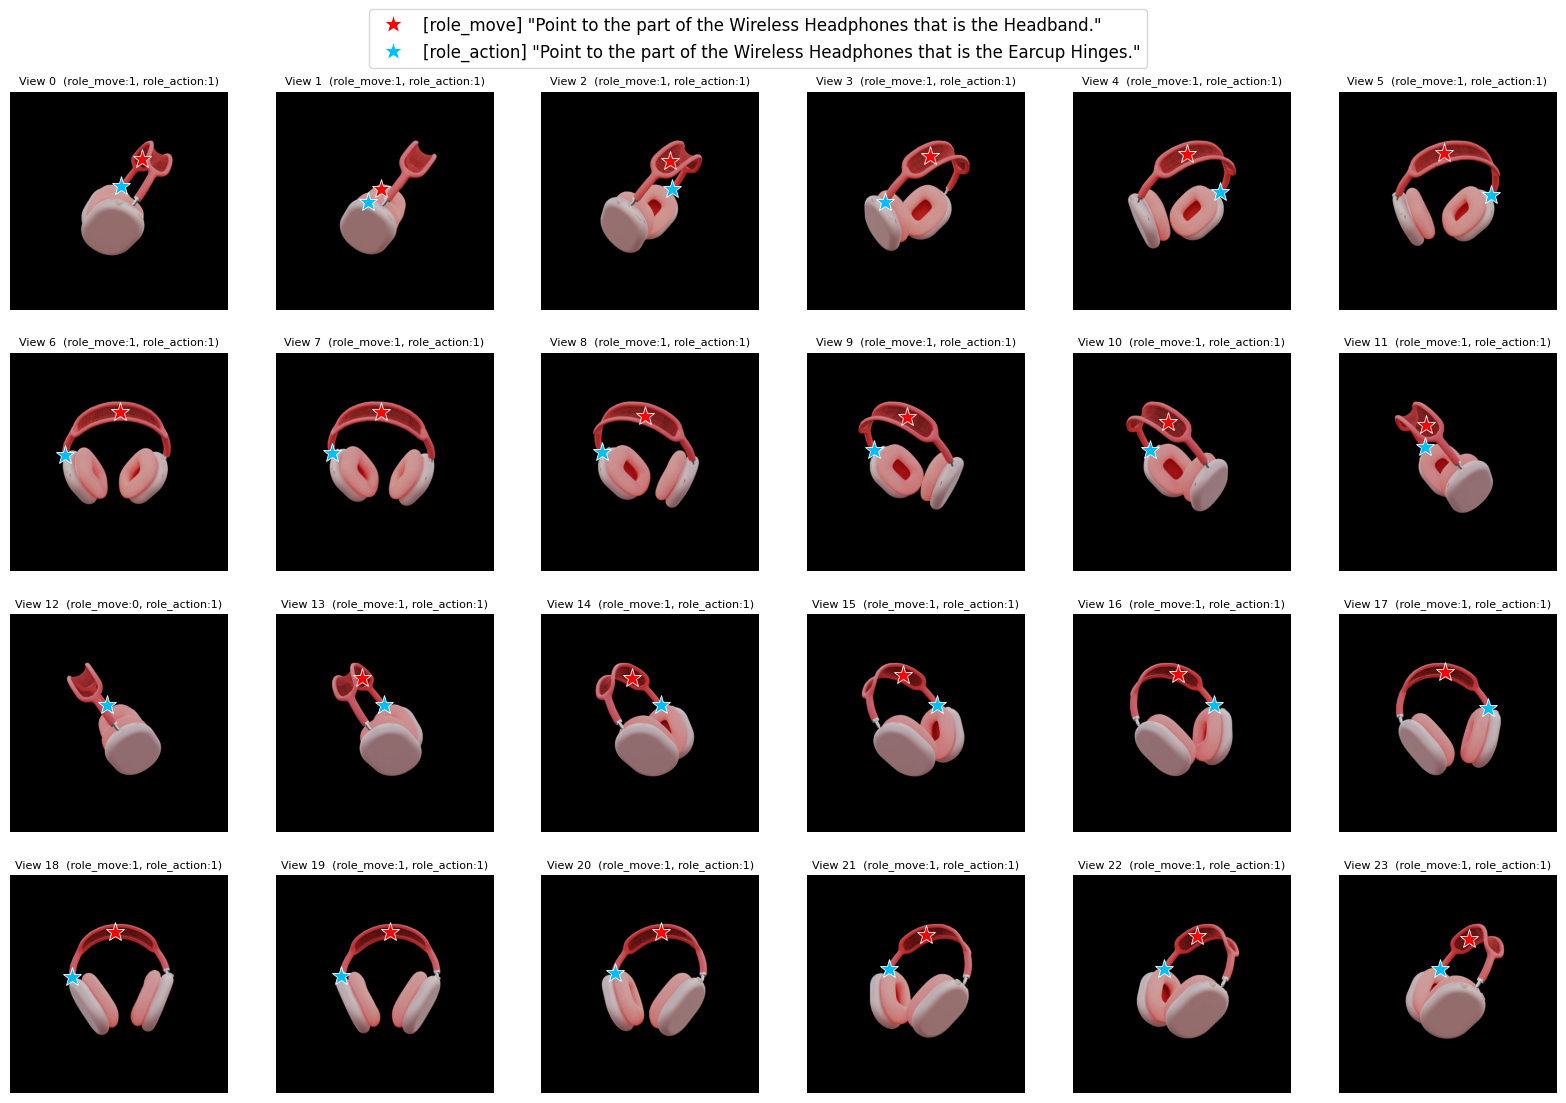

In [849]:
# 視覺化: 在同一組 grid 上畫所有 role 的點 (top-1 per role)，
#         以 ROLE_COLORS 區分，legend 標註對應的 query

fig, axes = plt.subplots(4, 6, figsize=(20, 13))

for i, ax in enumerate(axes.flat):
    if i < len(view_images_np):
        ax.imshow(view_images_np[i])
        for role in ROLES:
            pts = molmo_points_per_view_per_role[role][i]
            for pt in pts:
                ax.plot(pt[0], pt[1], '*', markersize=14,
                        c=ROLE_COLORS[role],
                        markeredgecolor='white', markeredgewidth=0.6)
        counts = ", ".join(
            f'{role}:{len(molmo_points_per_view_per_role[role][i])}' for role in ROLES
        )
        ax.set_title(f'View {i}  ({counts})', fontsize=8)
    ax.axis('off')

# 一個 legend，把 query 文字也帶上
legend_handles = [
    Line2D([0], [0], marker='*', linestyle='None',
           markerfacecolor=ROLE_COLORS[role],
           markeredgecolor='white', markeredgewidth=0.6,
           markersize=14,
           label=f'[{role}] "{ROLE_QUERIES[role]}"')
    for role in ROLES
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.95),
    ncol=1,
    fontsize=12,
    frameon=True,
)

# plt.suptitle("Molmo Affordance Points (top-1 per role)", fontsize=14, y=0.965)
# plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.show()

save_path = f'output/{id}/molmo_point.png'
fig.savefig(save_path, dpi=200, bbox_inches="tight")
# print(f"[INFO] saved figure to {save_path}")

#### Step 13: SAM2 Point Prompt → Mask → Probabilistic Heatmap

In [850]:
SAM2_CHECKPOINT = "checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
# print(f"Loading SAM2: {SAM2_CHECKPOINT} ...")

sam2_model = build_sam2(model_cfg, SAM2_CHECKPOINT, device=device)
sam2_predictor = SAM2ImagePredictor(sam2_model)
# print("SAM2 loaded!")

In [851]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def make_gaussian_weight(H, W, points, sigma=50):
    """
    建立以 Molmo 點為中心的 Gaussian weight map。
    多個點取 max（union of Gaussians）。sigma 越小越聚焦。
    """
    u = np.arange(W)[np.newaxis, :]  # [1, W]
    v = np.arange(H)[:, np.newaxis]  # [H, 1]

    weight = np.zeros((H, W), dtype=np.float32)
    for pt in points:
        dx = u - pt[0]
        dy = v - pt[1]
        g = np.exp(-(dx**2 + dy**2) / (2 * sigma**2))
        weight = np.maximum(weight, g)
    return weight


# ====== 參數設定 ======
GAUSSIAN_SIGMA = 77             # Gaussian 半徑 (像素)
MASK_SELECT = "best_iou"        # "smallest" or "best_iou"

# ====== Per-role × per-view: Molmo 點 → SAM2 mask logits → Gaussian-weighted heatmap ======
heatmaps_per_view_per_role = {role: [] for role in ROLES}

for role in ROLES:
    # print(f"\n=== SAM2 heatmaps for [{role}]  (mask={MASK_SELECT}, sigma={GAUSSIAN_SIGMA}) ===")
    points_per_view = molmo_points_per_view_per_role[role]

    for view_idx in tqdm.trange(len(view_images), desc=f"Heatmaps [{role}]"):
        points = points_per_view[view_idx]
        img_np = view_images_np[view_idx]

        if len(points) == 0:
            H, W = img_np.shape[:2]
            heatmaps_per_view_per_role[role].append(np.zeros((H, W), dtype=np.float32))
            continue

        sam2_predictor.set_image(img_np)

        point_coords = np.array(points, dtype=np.float32)
        point_labels = np.ones(len(points), dtype=np.int32)

        masks, iou_scores, low_res_logits = sam2_predictor.predict(
            point_coords=point_coords,
            point_labels=point_labels,
            multimask_output=True,
            return_logits=True,
        )

        if MASK_SELECT == "smallest":
            mask_areas = [(m > 0).sum() for m in masks]
            best_idx = np.argmin(mask_areas)
        else:
            best_idx = np.argmax(iou_scores)

        best_logits = masks[best_idx]
        heatmap = sigmoid(best_logits).astype(np.float32)

        H, W = img_np.shape[:2]
        gauss_w = make_gaussian_weight(H, W, points, sigma=GAUSSIAN_SIGMA)
        heatmap = heatmap * gauss_w

        heatmaps_per_view_per_role[role].append(heatmap)
        sam2_predictor.reset_predictor()

Heatmaps [role_action]:  17%|█▋        | 4/24 [00:00<00:01, 10.77it/s]/tmp/ipykernel_1269106/1664044608.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
Heatmaps [role_action]: 100%|██████████| 24/24 [00:02<00:00, 10.73it/s]


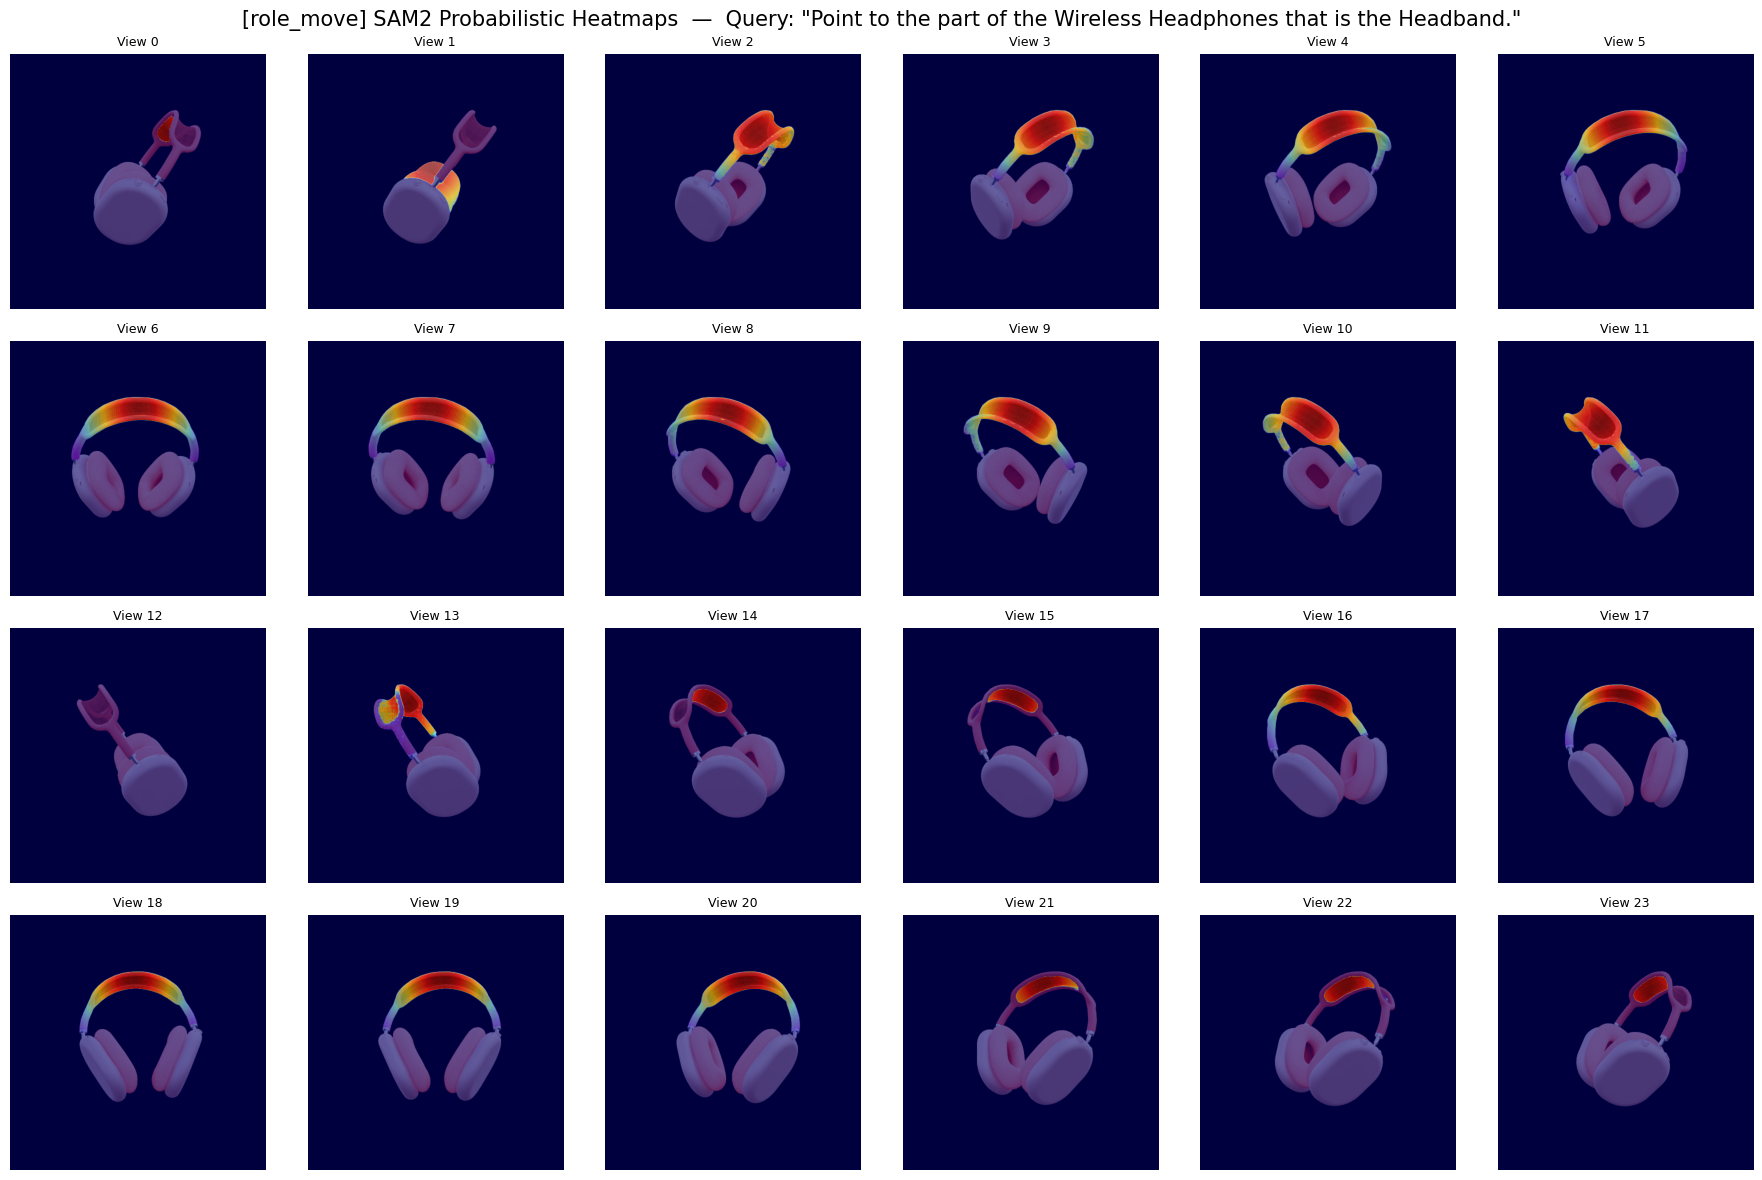

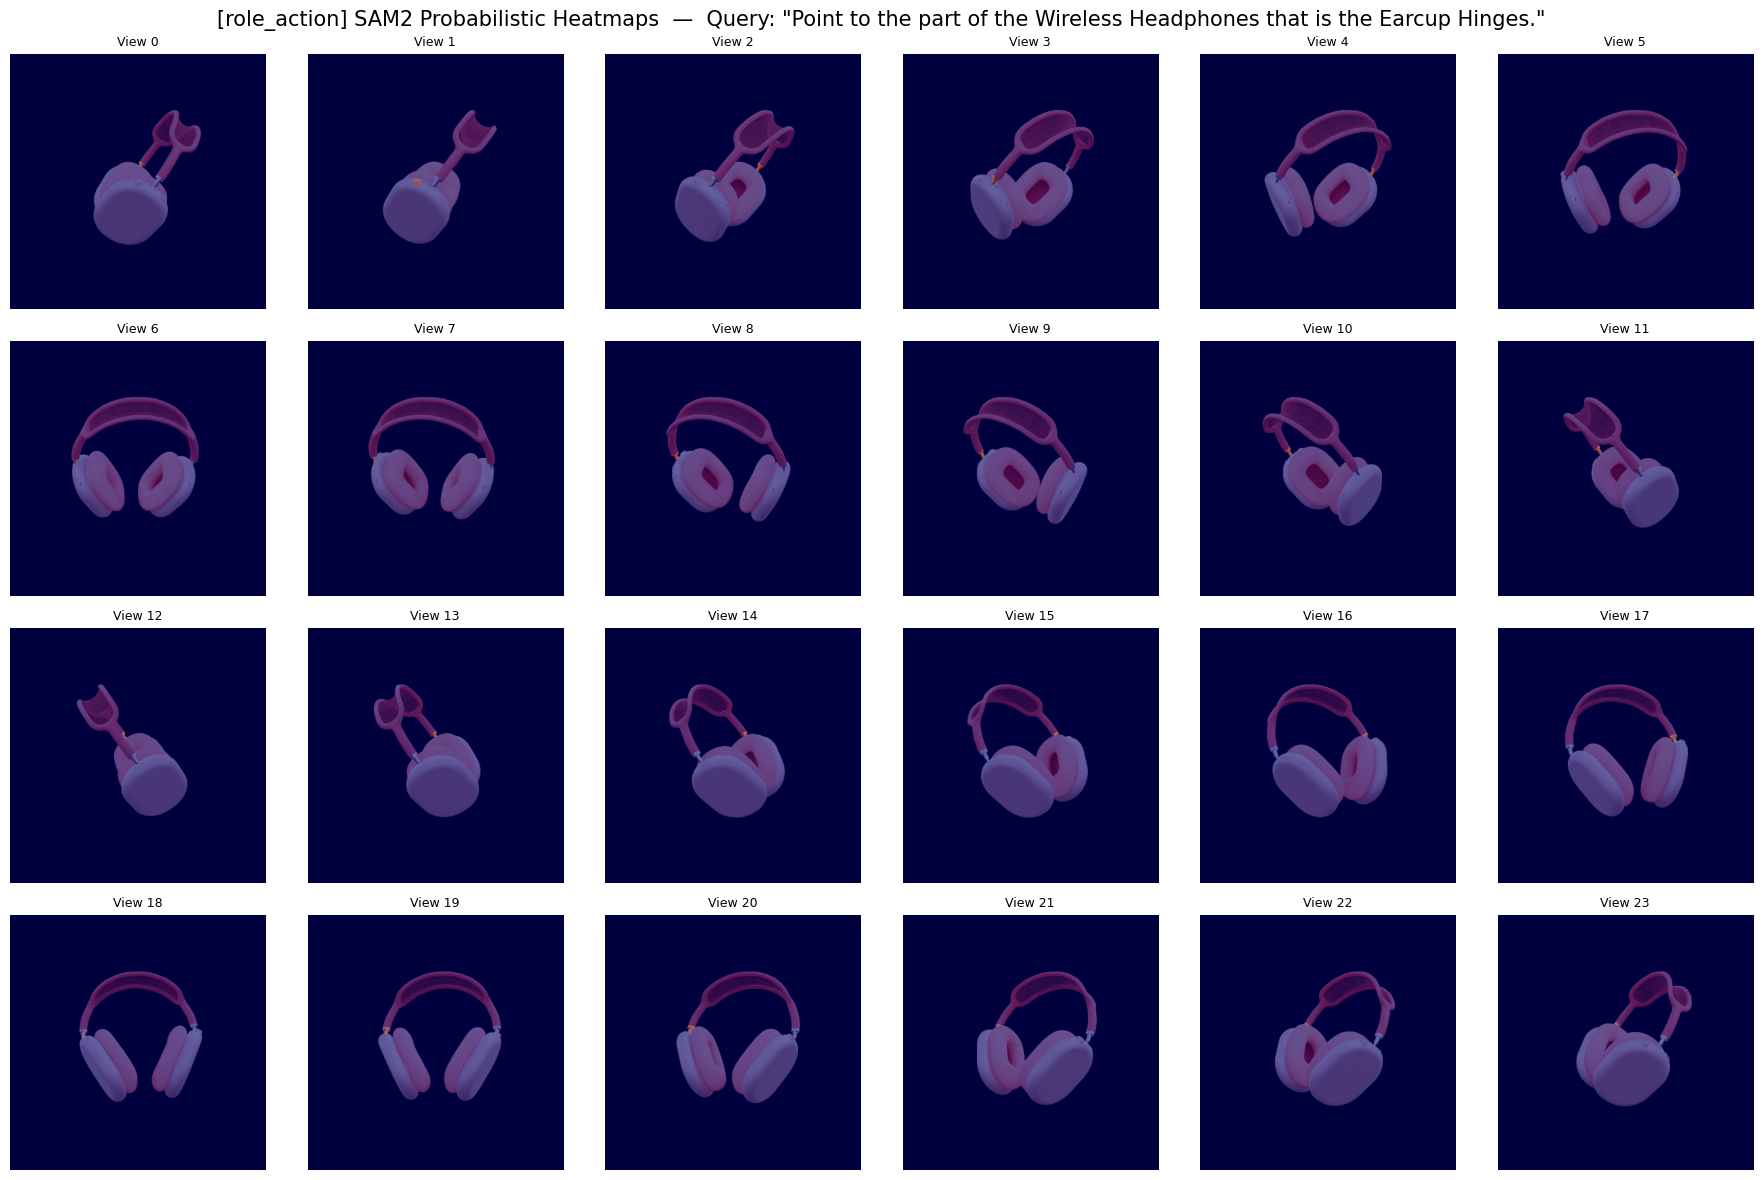

In [ ]:
# 視覺化: 每個 role 各畫一張 heatmap overlay grid
for role in ROLES:
    fig, axes = plt.subplots(4, 6, figsize=(18, 12))
    heatmaps = heatmaps_per_view_per_role[role]

    for i, ax in enumerate(axes.flat):
        if i < len(view_images_np):
            ax.imshow(view_images_np[i])
            ax.imshow(heatmaps[i], cmap='jet', alpha=0.5, vmin=0, vmax=1)
            ax.set_title(f'View {i}', fontsize=9)
        ax.axis('off')

    plt.suptitle(f'[{role}] SAM2 Probabilistic Heatmaps  —  Query: "{ROLE_QUERIES[role]}"', fontsize=15)
    plt.tight_layout()
    # plt.show()
    save_path = f'output/{id}/sam2_{role}_heatmap.png'
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

#### Step 14: 多視角 Voting — 把 2D Heatmap 投回原始 3D 點雲

In [ ]:
# # 載入 xyzc.npy
# npy_files = glob.glob(pc_path)
# assert len(npy_files) > 0, f'No xyzc.npy found in {pc_path}'
# npy_path = npy_files[0]
# # print(f'Loading GT point cloud: {npy_path}')

# gt_data = np.load(npy_path)
# # print(f'  GT shape: {gt_data.shape}')

# # 前 3 欄 = xyz, 後面的欄位是 affordance heatmap (不使用)
# gt_points = gt_data[:, :3].astype(np.float32)
# gt_colors = np.ones((len(gt_points), 3), dtype=np.float32) * 0.7  # 灰色 placeholder

# gt_points = gt_points[:, [0, 2, 1]]  # 先交換 Y 和 Z
# gt_points[:, 1] *= -1                 # 只翻轉新的 Y

# # print(f'  GT bounds:            min={gt_points.min(axis=0)}, max={gt_points.max(axis=0)}')
# # print(f'  Reconstructed bounds: min={all_points.min(axis=0)}, max={all_points.max(axis=0)}')

# # Plotly: 以 affordance score 為顏色
# fig = go.Figure()

# fig.add_trace(go.Scatter3d(
#     x=gt_points[:, 0],
#     y=gt_points[:, 1],
#     z=gt_points[:, 2],
#     mode='markers',
#     marker=dict(
#         size=1,
#         color=gt_colors,
#         # colorscale='Jet',
#         cmin=0, cmax=1,
#         # colorbar=dict(title='Affordance<br>Score'),
#         opacity=0.8,
#     ),
#     # text=[f'score={s:.3f}, views={c}' for s, c in zip(gt_colors, counts_sub)],
#     hoverinfo='text',
#     name='3D Affordance'
# ))

# fig.update_layout(
#     title=f'Ground Truth Object Point Cloud ({len(gt_points):,} points displayed, subsampled 1/{1})',
#     scene=dict(aspectmode='data', xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
#     width=900, height=700
# )

# fig.show()

In [854]:
def project_and_sample_heatmaps(points, heatmaps, cameras, K_list, depths, depth_tolerance=0.05):
    """
    把原始 3D 點雲投影到每個 view 的 2D heatmap 上，做 voting aggregation。

    Args:
        points: [N, 3] 原始 3D 點雲 (來自 Step 8)
        heatmaps: list of [H, W] 每個 view 的 2D heatmap
        cameras: list of (c2w, w2c) tuples for each view
        K_list: list of [3, 3] 內參矩陣
        depths: list of [H, W] 深度圖 (用於可見性檢查)
        depth_tolerance: 深度容差 (相對值)，用於判斷點是否被遮擋

    Returns:
        scores: [N] 每個點的 aggregated affordance score
        counts: [N] 每個點被多少個 view 看到
    """
    N = len(points)
    num_views = len(heatmaps)

    score_sum = np.zeros(N, dtype=np.float32)
    view_counts = np.zeros(N, dtype=np.int32)

    points_homo = np.hstack([points, np.ones((N, 1))])  # [N, 4]

    for view_idx in range(num_views):
        c2w, w2c = cameras[view_idx]
        K = K_list[view_idx]
        heatmap = heatmaps[view_idx]
        depth_map = depths[view_idx]
        H, W = heatmap.shape

        cam_coords = (w2c @ points_homo.T).T
        cam_xyz = cam_coords[:, :3]

        in_front = cam_xyz[:, 2] > 0

        pixel_homo = (K @ cam_xyz.T).T
        pixel_uv = pixel_homo[:, :2] / pixel_homo[:, 2:3]

        u = pixel_uv[:, 0]
        v = pixel_uv[:, 1]
        in_bounds = (u >= 0) & (u < W) & (v >= 0) & (v < H)

        proj_depth = cam_xyz[:, 2]

        u_int = np.clip(u.astype(np.int32), 0, W - 1)
        v_int = np.clip(v.astype(np.int32), 0, H - 1)
        sampled_depth = depth_map[v_int, u_int]

        visible = (sampled_depth > 0) & (proj_depth < sampled_depth * (1 + depth_tolerance))

        valid_mask = in_front & in_bounds & visible

        sampled_scores = np.zeros(N, dtype=np.float32)
        sampled_scores[valid_mask] = heatmap[v_int[valid_mask], u_int[valid_mask]]

        score_sum += sampled_scores
        view_counts += valid_mask.astype(np.int32)

    final_scores = np.zeros(N, dtype=np.float32)
    seen_mask = view_counts > 0
    final_scores[seen_mask] = score_sum[seen_mask] / view_counts[seen_mask]

    return final_scores, view_counts


# ====== 準備投影所需的相機參數 (所有 role 共用) ======
cameras = []      # list of (c2w, w2c)
K_list = []
depth_maps = []

for view_idx in tqdm.trange(NUM_VIEWS_TO_LOAD, desc="Preparing camera matrices"):
    json_path = f'{img_folder_path}/{view_idx:05d}/{view_idx:05d}.json'
    depth_path = f'{img_folder_path}/{view_idx:05d}/{view_idx:05d}_nd.exr'

    c2w = read_camera_matrix(json_path)
    c2w_converted = convert_pose_flip_yz(c2w)
    w2c = np.linalg.inv(c2w_converted)

    camera_pos = c2w[:3, 3]
    depth, _ = read_depth_from_exr(depth_path, camera_pos)

    H, W = depth.shape
    K = get_intrinsic_matrix(H, W)

    cameras.append((c2w, w2c))
    K_list.append(K)
    depth_maps.append(depth)


# ====== Per-role voting aggregation ======
affordance_scores_per_role = {}
visibility_counts_per_role = {}

for role in ROLES:
    print(f"\n=== Voting Aggregation for [{role}] ===")
    print(f"Projecting {len(gt_points):,} GT points to {len(heatmaps_per_view_per_role[role])} views...")
    scores, counts = project_and_sample_heatmaps(
        gt_points,
        heatmaps_per_view_per_role[role],
        cameras, K_list, depth_maps,
        depth_tolerance=0.15,
    )
    affordance_scores_per_role[role] = scores
    visibility_counts_per_role[role] = counts

    # print(f"  score range: [{scores.min():.4f}, {scores.max():.4f}]   mean: {scores.mean():.4f}")
    # print(f"  visibility:  min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f} views/point")
    # print(f"  points seen by 0 views: {(counts == 0).sum():,}")

Preparing camera matrices: 100%|██████████| 24/24 [00:00<00:00, 80.73it/s]



=== Voting Aggregation for [role_move] ===
Projecting 16,384 GT points to 24 views...

=== Voting Aggregation for [role_action] ===
Projecting 16,384 GT points to 24 views...


In [855]:
# ====== 載入 reconstruction point cloud ======
recon_data = np.load(f'output/{id}/recon.npz')
recon_points = recon_data["points"].astype(np.float32)

print(f"Loaded reconstruction points: {recon_points.shape}")


# ====== 準備投影所需的相機參數 ======
cameras = []      # list of (c2w, w2c)
K_list = []
depth_maps = []

for view_idx in tqdm.trange(NUM_VIEWS_TO_LOAD, desc="Preparing camera matrices"):
    json_path = f'{img_folder_path}/{view_idx:05d}/{view_idx:05d}.json'
    depth_path = f'{img_folder_path}/{view_idx:05d}/{view_idx:05d}_nd.exr'

    c2w = read_camera_matrix(json_path)
    c2w_converted = convert_pose_flip_yz(c2w)
    w2c = np.linalg.inv(c2w_converted)

    camera_pos = c2w[:3, 3]
    depth, _ = read_depth_from_exr(depth_path, camera_pos)

    H, W = depth.shape
    K = get_intrinsic_matrix(H, W)

    cameras.append((c2w, w2c))
    K_list.append(K)
    depth_maps.append(depth)


# ====== Per-role voting aggregation on reconstruction ======
affordance_scores_per_role = {}
visibility_counts_per_role = {}

for role in ROLES:
    print(f"\n=== Voting Aggregation for [{role}] ===")
    print(f"Projecting {len(recon_points):,} reconstruction points to {len(heatmaps_per_view_per_role[role])} views...")

    scores, counts = project_and_sample_heatmaps(
        recon_points,
        heatmaps_per_view_per_role[role],
        cameras,
        K_list,
        depth_maps,
        depth_tolerance=0.15,
    )

    affordance_scores_per_role[role] = scores
    visibility_counts_per_role[role] = counts

    print(f"  score range: [{scores.min():.4f}, {scores.max():.4f}]")
    print(f"  visible points: {(counts > 0).sum():,} / {len(counts):,}")

Loaded reconstruction points: (613469, 3)


Preparing camera matrices:   0%|          | 0/24 [00:00<?, ?it/s]

Preparing camera matrices: 100%|██████████| 24/24 [00:00<00:00, 83.45it/s]



=== Voting Aggregation for [role_move] ===
Projecting 613,469 reconstruction points to 24 views...
  score range: [0.0000, 0.9997]
  visible points: 613,338 / 613,469

=== Voting Aggregation for [role_action] ===
Projecting 613,469 reconstruction points to 24 views...
  score range: [0.0000, 0.4981]
  visible points: 613,338 / 613,469


In [856]:
# # ====== 3D 視覺化: 每個 role 一張 plot ======
# import plotly.graph_objects as go

# subsample = 1
# idx = np.arange(0, len(gt_points), subsample)
# pts_sub = gt_points[idx]
# print(f"Subsampled: {len(pts_sub):,} points (1/{subsample})")

# for role in ROLES:
#     scores_sub = affordance_scores_per_role[role][idx]
#     counts_sub = visibility_counts_per_role[role][idx]

#     fig = go.Figure()
#     fig.add_trace(go.Scatter3d(
#         x=pts_sub[:, 0],
#         y=-pts_sub[:, 1],
#         z=-pts_sub[:, 2],
#         mode='markers',
#         marker=dict(
#             size=1,
#             color=scores_sub,
#             colorscale=ROLE_COLORSCALES[role],
#             cmin=0, cmax=1,
#             colorbar=dict(title=f'{role}<br>score'),
#             opacity=0.85,
#         ),
#         text=[f'score={s:.3f}, views={c}' for s, c in zip(scores_sub, counts_sub)],
#         hoverinfo='text',
#         name=role,
#     ))
#     fig.update_layout(
#         title=f'[{role}] Affordance Heatmap  —  Query: "{ROLE_QUERIES[role]}"<br>'
#               f'({len(pts_sub):,} points, subsampled 1/{subsample})',
#         scene=dict(aspectmode='data', xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
#         width=900, height=700,
#     )
#     fig.show()

In [857]:
# ====== 3D 視覺化: 每個 role 一張 plot (Reconstruction Version) ======
import plotly.graph_objects as go

subsample = 20

idx = np.arange(0, len(recon_points), subsample)
pts_sub = recon_points[idx]

print(f"Subsampled: {len(pts_sub):,} points (1/{subsample})")

for role in ROLES:
    scores_sub = affordance_scores_per_role[role][idx]
    counts_sub = visibility_counts_per_role[role][idx]

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=pts_sub[:, 0],
        y=-pts_sub[:, 1],
        z=pts_sub[:, 2],
        mode='markers',
        marker=dict(
            size=1,
            color=scores_sub,
            colorscale=ROLE_COLORSCALES[role],
            cmin=0,
            cmax=1,
            colorbar=dict(title=f'{role}<br>score'),
            opacity=0.85,
        ),
        text=[
            f'score={s:.3f}, views={c}'
            for s, c in zip(scores_sub, counts_sub)
        ],
        hoverinfo='text',
        name=role,
    ))

    fig.update_layout(
        title=(
            f'[{role}] Affordance Heatmap  —  '
            f'Query: "{ROLE_QUERIES[role]}"<br>'
            f'({len(pts_sub):,} points, subsampled 1/{subsample})'
        ),
        scene=dict(
            aspectmode='data',
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
        ),
        width=900,
        height=700,
    )

    fig.show()

Subsampled: 30,674 points (1/20)
